## Load California Housing Prices

In [ ]:
import pandas as pd

df = pd.read_csv('/content/housing.csv')
display(df.tail())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND
20639,-121.24,39.37,16.0,2785.0,616.0,1387.0,530.0,2.3886,89400.0,INLAND


## DS Summary

In [ ]:
import numpy as np

print(df.info())
display(df.select_dtypes(include=[np.number]).describe())
display(df.select_dtypes(exclude=[np.number]).describe())


print("Nan values:")
display(df.isna().sum().sort_values(ascending=False))
print("number of values with 500001.000000 median house value")
print(df[df['median_house_value'] == 500001.000000].shape[0])



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,ocean_proximity
count,20640
unique,5
top,<1H OCEAN
freq,9136


Nan values:


,0
total_bedrooms,207
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


number of values with 500001.000000 median house value
965


## Distribution Histograms

longitude: max=-114.31, unique=844, bins=40, discrete=False


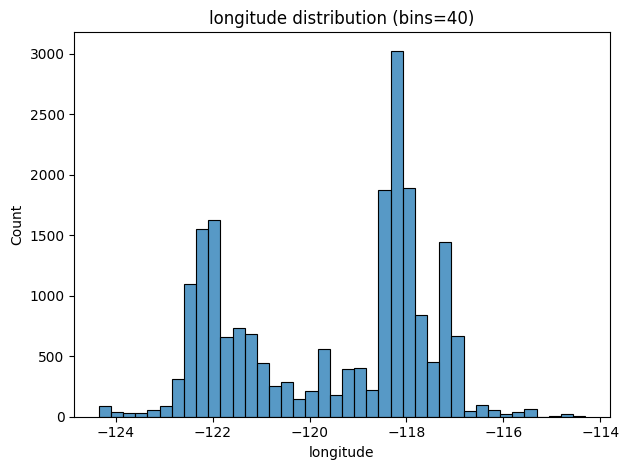

latitude: max=41.95, unique=862, bins=40, discrete=False


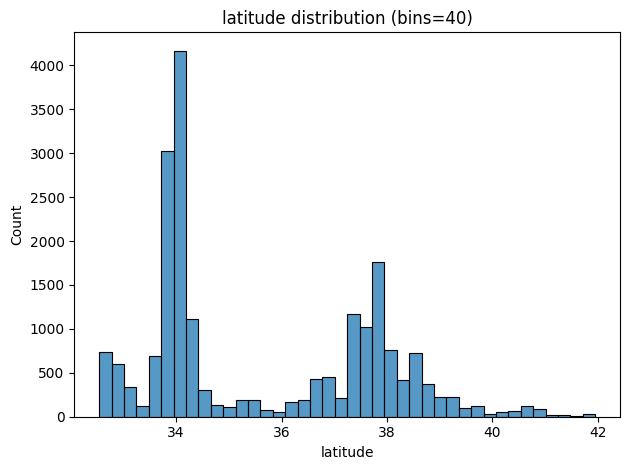

housing_median_age: max=52.0, unique=52, bins=40, discrete=False


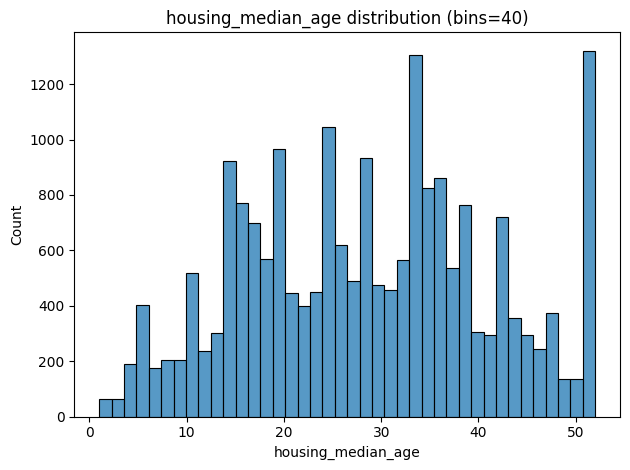

total_rooms: max=39320.0, unique=5926, bins=40, discrete=False


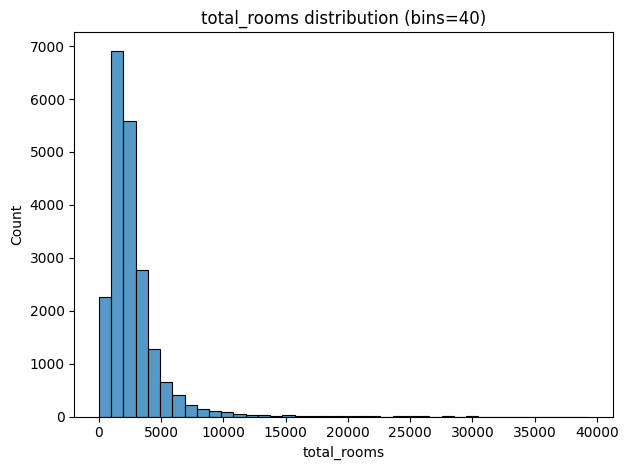

total_bedrooms: max=6445.0, unique=1923, bins=40, discrete=False


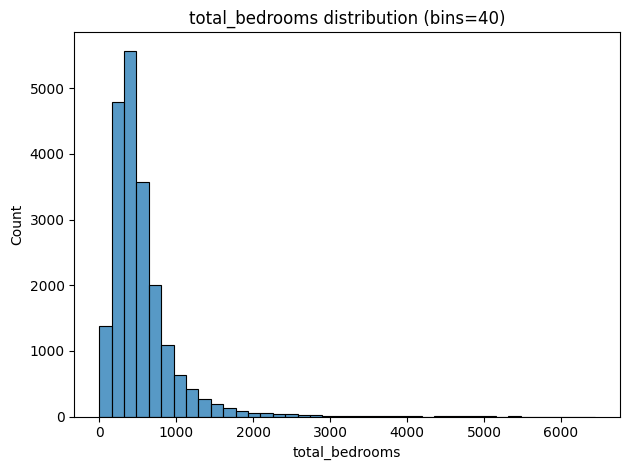

population: max=35682.0, unique=3888, bins=40, discrete=False


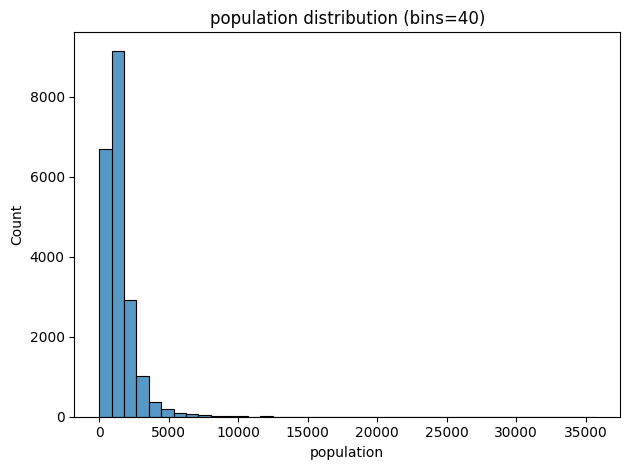

households: max=6082.0, unique=1815, bins=40, discrete=False


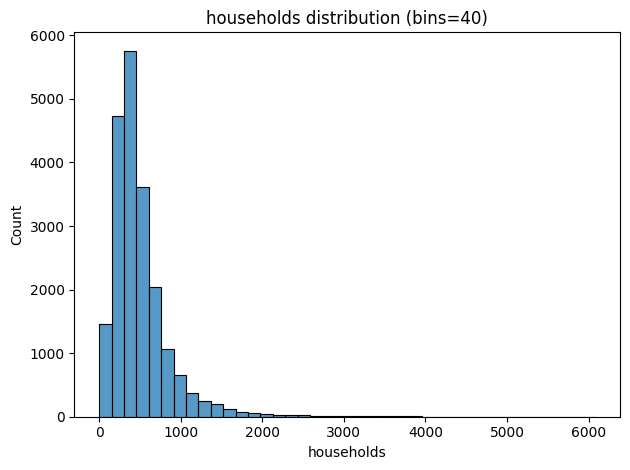

median_income: max=15.0001, unique=12928, bins=40, discrete=False


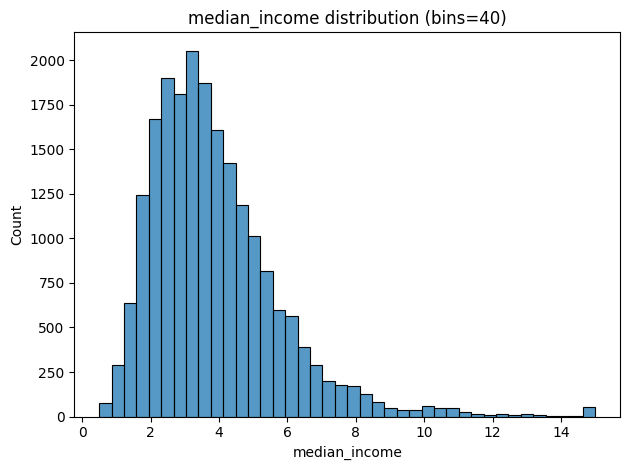

median_house_value: max=500001.0, unique=3842, bins=40, discrete=False


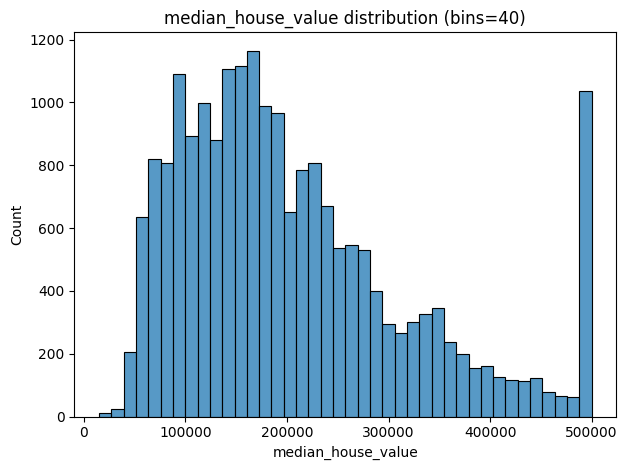

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
  cleaned = df[c].dropna()
  max_val = cleaned.max()
  n = len(cleaned)
  # Decide bins:
  # If data look like small-range integers (few unique values) use that count (discrete histogram)
  n_unique = cleaned.nunique()
  use_discrete = False
  if pd.api.types.is_integer_dtype(cleaned) and 1 < n_unique <= 20:
      bins = n_unique
      use_discrete = True
  else:
      # Fallback: Freedman–Diaconis inspired simple heuristic (sqrt fallback) capped
      # sqrt(n) is a simple rule-of-thumb; keep within [10, 40]
      bins = int(np.sqrt(n)) if n > 0 else 1
      bins = max(10, min(40, bins))
  print(f'{c}: max={max_val}, unique={n_unique}, bins={bins}, discrete={use_discrete}')
  sns.histplot(cleaned, bins=bins, discrete=use_discrete)
  plt.title(f'{c} distribution (bins={bins})')
  plt.tight_layout()
  plt.show()

## mapbox

In [ ]:
import pandas as pd
import plotly.express as px

# Plot houses
fig = px.scatter_mapbox(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="ocean_proximity",
    hover_data=["median_house_value", "population"],
    color="ocean_proximity",
    zoom=5,
    height=700
)

# Marker style
fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.3,
    )
)

# Map style and layout
fig.update_layout(mapbox_style="carto-positron")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})
fig.update_layout(
    legend=dict(
        orientation="h",
        yanchor="bottom",
        xanchor="center",
        x=0.5
    )
)

fig.show()

## Handle missing values
total_bedrooms - 207/20640 missing - 1%
so we can use median


In [ ]:
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print("Missing values after filling:")
display(df.isna().sum().sort_values(ascending=False))


Missing values after filling:


,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## Handle Outliers

### compare original vs log

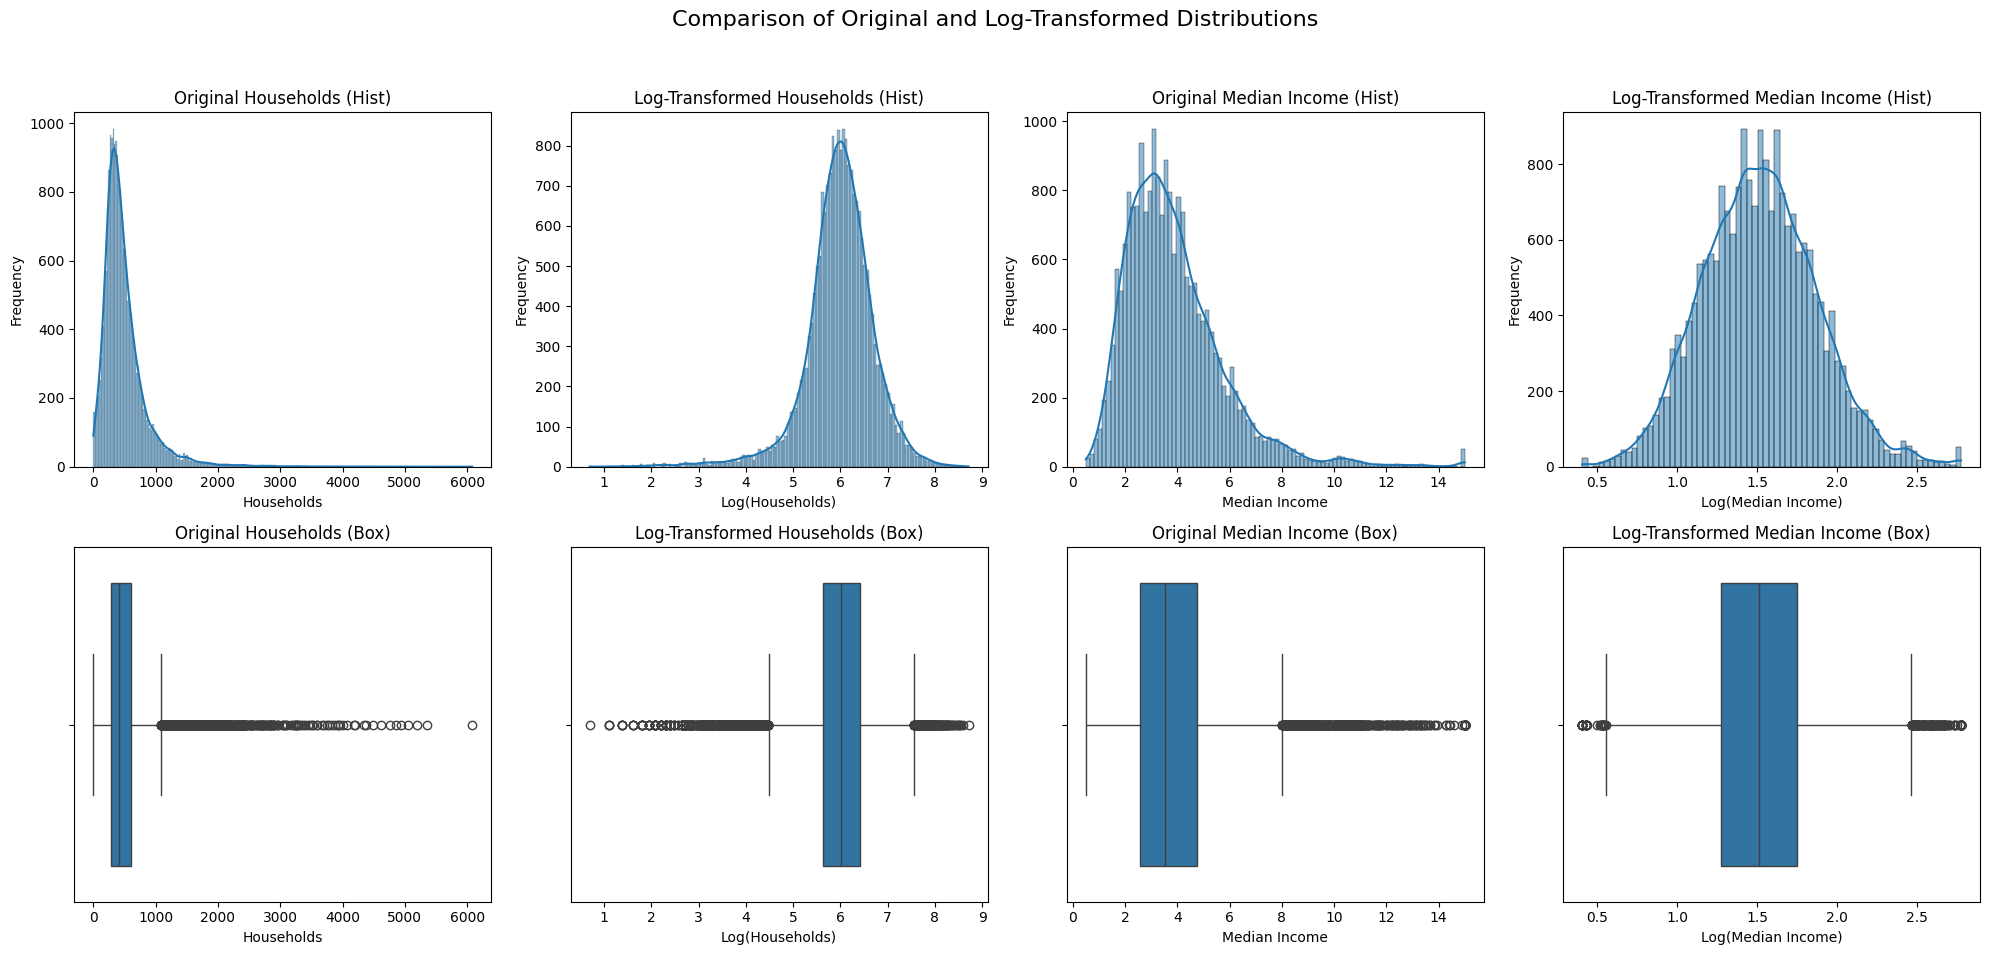

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select the columns
households_original = df['households'].copy()
median_income_original = df['median_income'].copy()

# Apply log transformation
households_log_transformed = np.log1p(households_original)
median_income_log_transformed = np.log1p(median_income_original)

# Create subplots for visualization
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Comparison of Original and Log-Transformed Distributions', fontsize=16)

# Households - Original Histogram
sns.histplot(households_original, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original Households (Hist)')
axes[0, 0].set_xlabel('Households')
axes[0, 0].set_ylabel('Frequency')

# Households - Log-Transformed Histogram
sns.histplot(households_log_transformed, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Log-Transformed Households (Hist)')
axes[0, 1].set_xlabel('Log(Households)')
axes[0, 1].set_ylabel('Frequency')

# Households - Original Boxplot
sns.boxplot(x=households_original, ax=axes[1, 0])
axes[1, 0].set_title('Original Households (Box)')
axes[1, 0].set_xlabel('Households')

# Households - Log-Transformed Boxplot
sns.boxplot(x=households_log_transformed, ax=axes[1, 1])
axes[1, 1].set_title('Log-Transformed Households (Box)')
axes[1, 1].set_xlabel('Log(Households)')

# Median Income - Original Histogram
sns.histplot(median_income_original, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Original Median Income (Hist)')
axes[0, 2].set_xlabel('Median Income')
axes[0, 2].set_ylabel('Frequency')

# Median Income - Log-Transformed Histogram
sns.histplot(median_income_log_transformed, kde=True, ax=axes[0, 3])
axes[0, 3].set_title('Log-Transformed Median Income (Hist)')
axes[0, 3].set_xlabel('Log(Median Income)')
axes[0, 3].set_ylabel('Frequency')

# Median Income - Original Boxplot
sns.boxplot(x=median_income_original, ax=axes[1, 2])
axes[1, 2].set_title('Original Median Income (Box)')
axes[1, 2].set_xlabel('Median Income')

# Median Income - Log-Transformed Boxplot
sns.boxplot(x=median_income_log_transformed, ax=axes[1, 3])
axes[1, 3].set_title('Log-Transformed Median Income (Box)')
axes[1, 3].set_xlabel('Log(Median Income)')


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Detect ol

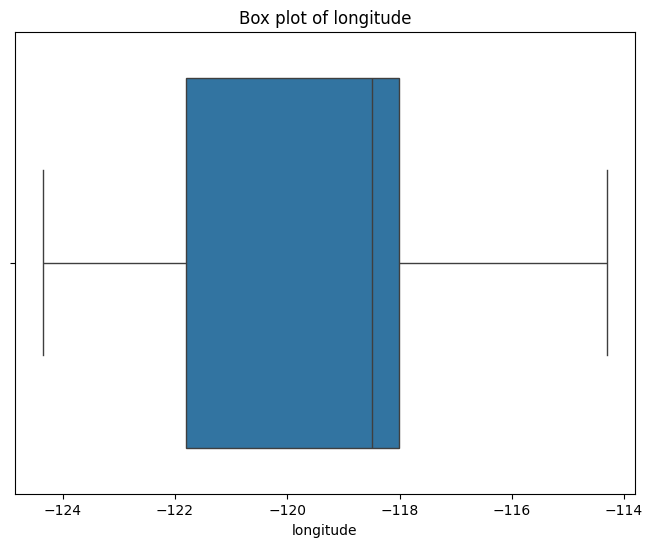

Number of outliers in 'longitude': 0


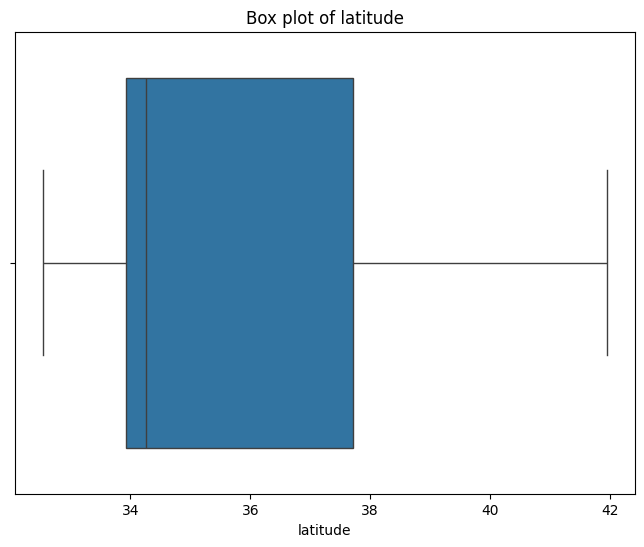

Number of outliers in 'latitude': 0


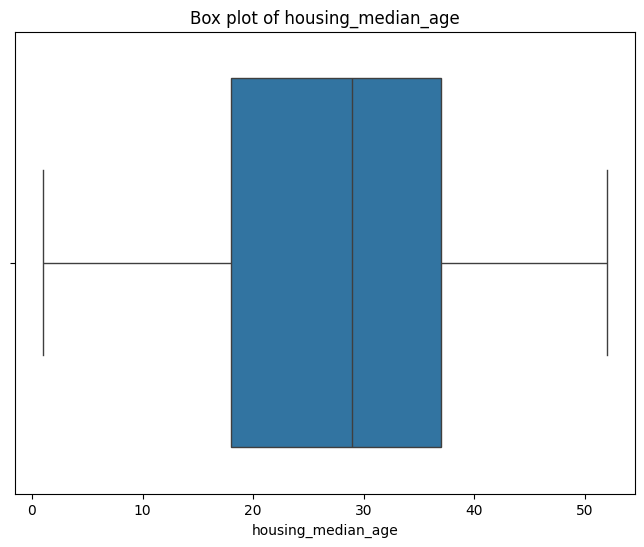

Number of outliers in 'housing_median_age': 0


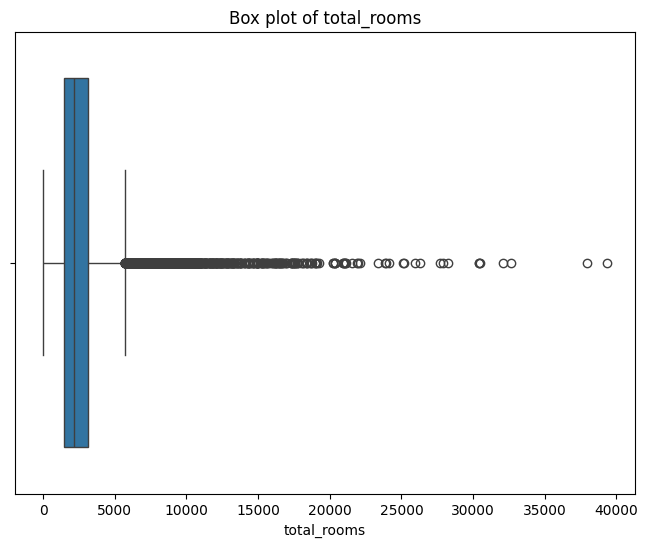

Number of outliers in 'total_rooms': 1287


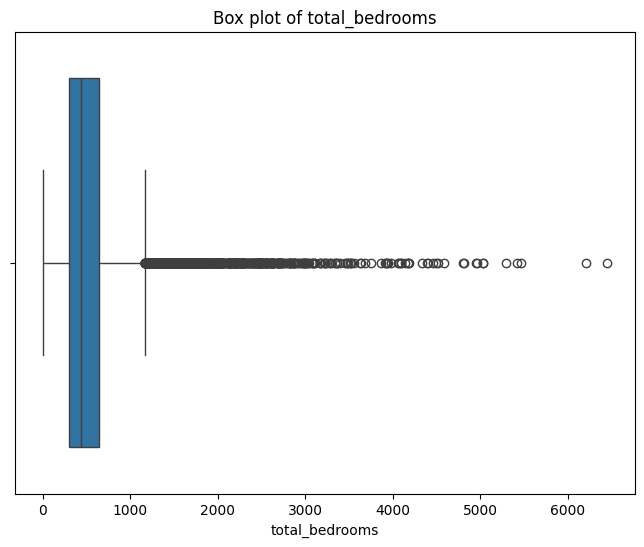

Number of outliers in 'total_bedrooms': 1306


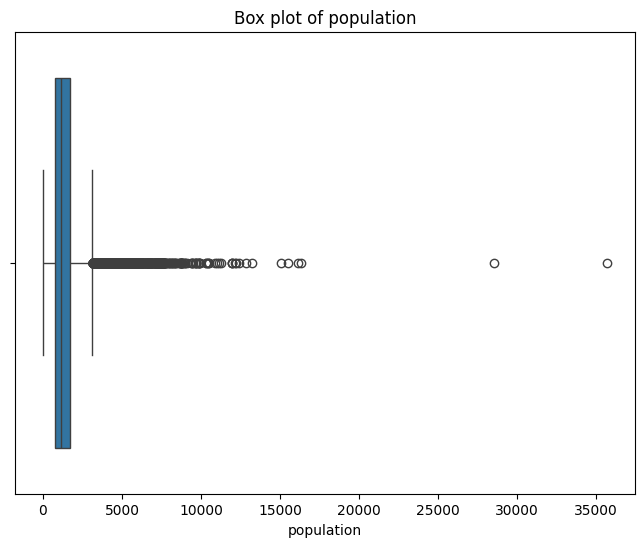

Number of outliers in 'population': 1196


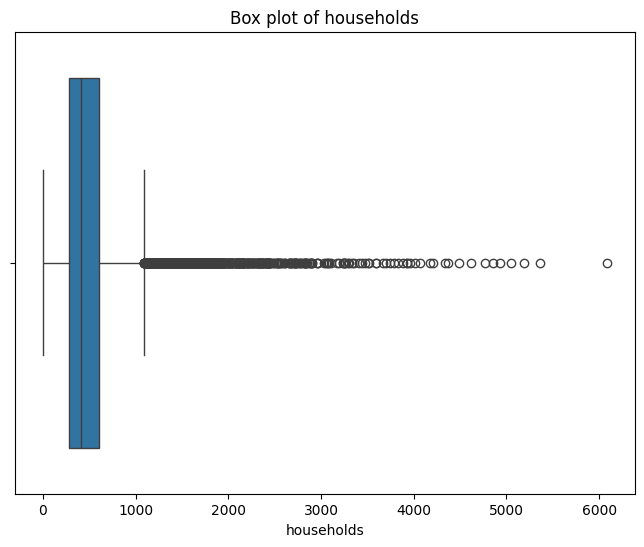

Number of outliers in 'households': 1220


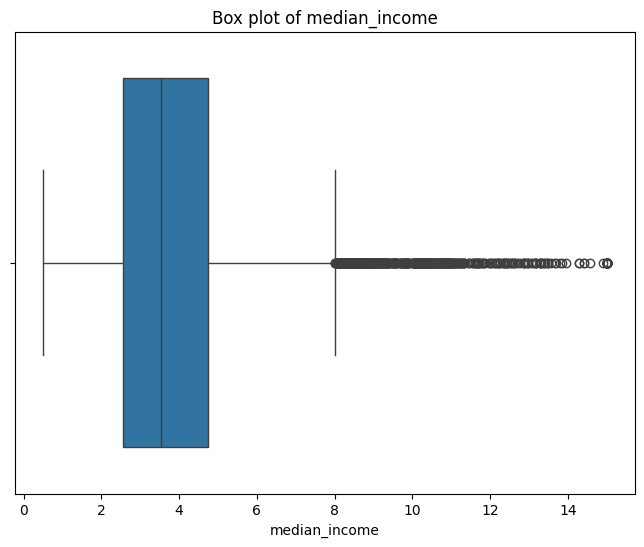

Number of outliers in 'median_income': 681


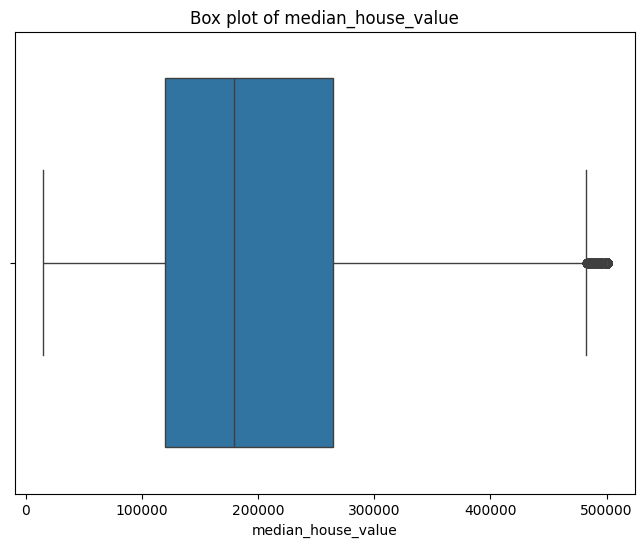

Number of outliers in 'median_house_value': 1071
Columns to handle outliers: ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

handle_ol = []
# Create box plots and print the number of outliers for each numerical column
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

    # Calculate the number of outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
      handle_ol.append(col)

    print(f"Number of outliers in '{col}': {len(outliers)}")

print(f"Columns to handle outliers: {handle_ol}")

### Log Transformation

In [ ]:
# import numpy as np

for col in handle_ol:
    df[col] = np.log1p(df[col])

print("Log transformation applied to columns:", handle_ol)

Log transformation applied to columns: ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']


### log1p boxplot

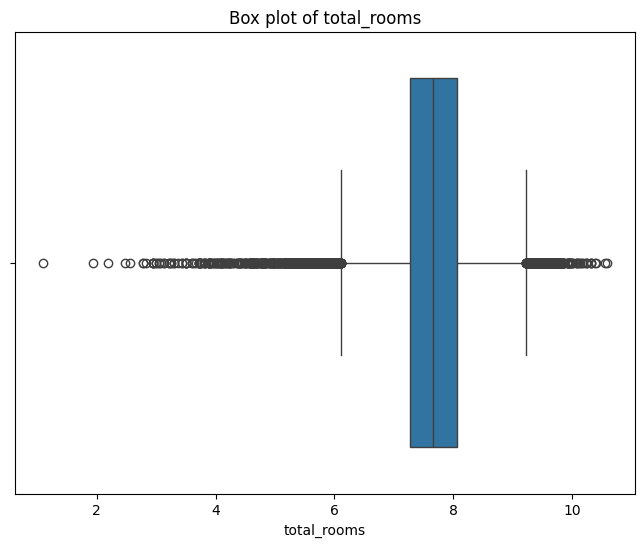

Number of outliers in 'total_rooms': 957


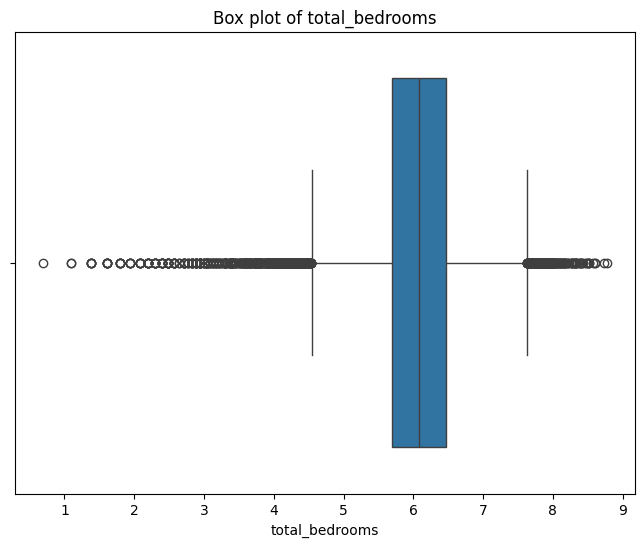

Number of outliers in 'total_bedrooms': 836


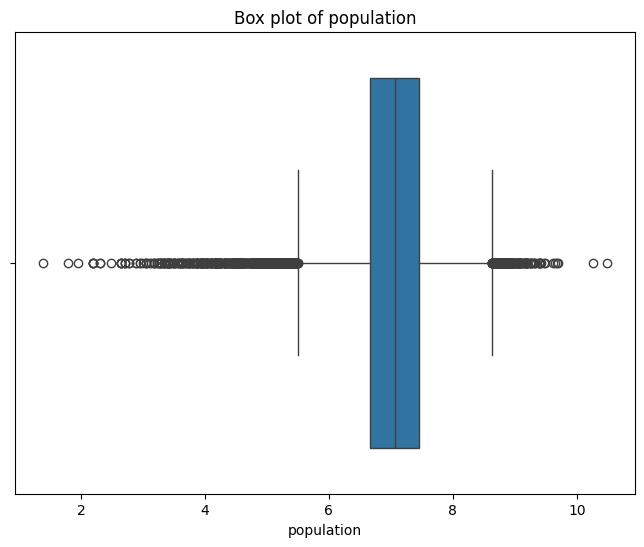

Number of outliers in 'population': 848


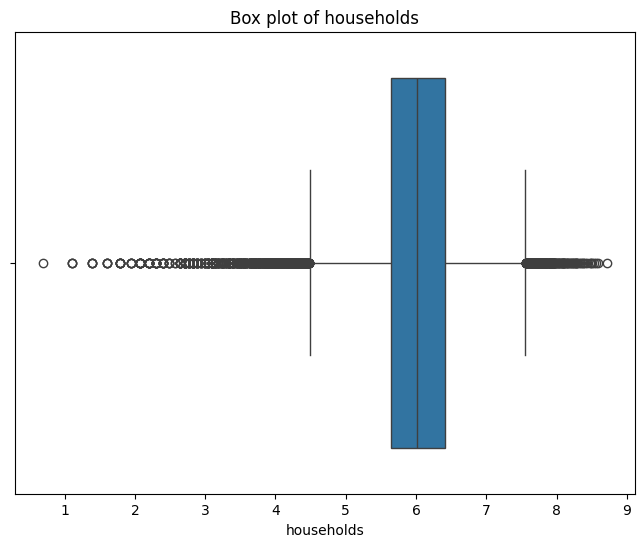

Number of outliers in 'households': 882


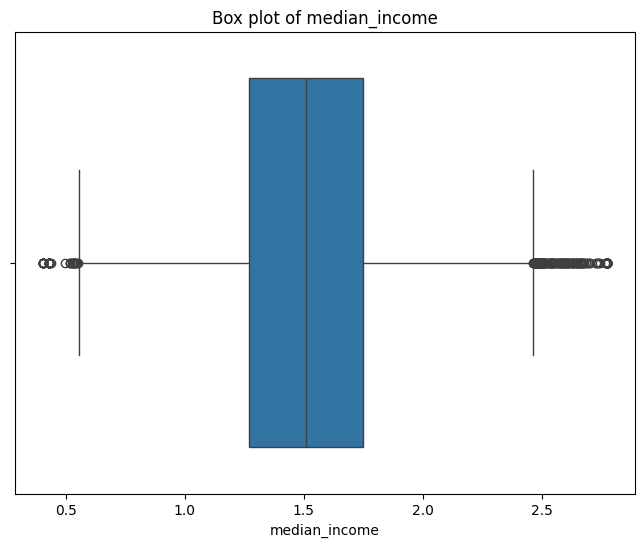

Number of outliers in 'median_income': 226


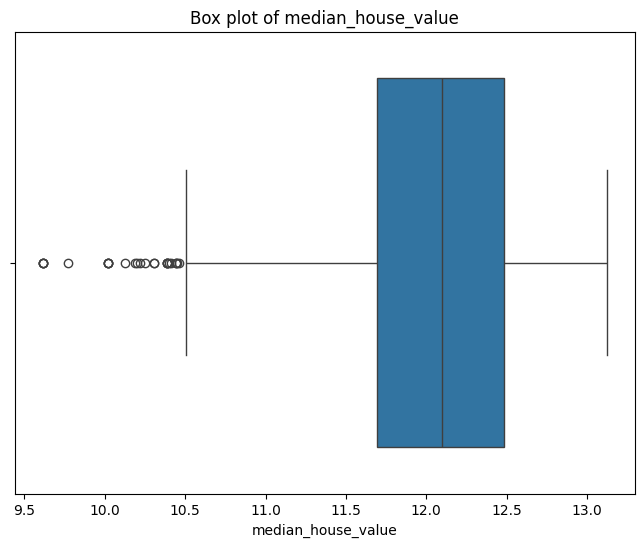

Number of outliers in 'median_house_value': 26


In [ ]:
for col in handle_ol:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.xlabel(col)
    plt.show()

    # Calculate the number of outliers using IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]['longitude']
    print(f"Number of outliers in '{col}': {len(outliers)}")


## Feature Engeneering

### Coordinate Engineering
1. Identified the top 10 most populous cities in California.
2. Removed Oakland, Long Beach, and Anaheim because they are very close to larger nearby cities.
3. Created a new column df["50km"] indicating the nearest big city within a 50 km radius for each house.

In [ ]:
import pandas as pd
import plotly.express as px

# Top 10 cities with approximate coordinates
cities = pd.DataFrame({
    "city": ["Los Angeles", "San Diego", "San Jose", "San Francisco", "Fresno",
             "Sacramento", "Long Beach", "Oakland", "Bakersfield", "Anaheim"],
    "latitude": [34.0522, 32.7157, 37.3382, 37.7749, 36.7378,
                 38.5816, 33.7701, 37.8044, 35.3733, 33.8366],
    "longitude": [-118.2437, -117.1611, -121.8863, -122.4194, -119.7871,
                  -121.4944, -118.1937, -122.2711, -119.0187, -117.9143]
})

cities_to_drop = ["Oakland", "Long Beach", "Anaheim"]
cities = cities[~cities['city'].isin(cities_to_drop)].reset_index(drop=True)

# Plot cities
fig = px.scatter_mapbox(
    cities,
    lat="latitude",
    lon="longitude",
    hover_name="city",
    zoom=5,
    height=600
)

fig.update_traces(
    marker=dict(
        size=10,
        color="red"
    )
)

fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

In [ ]:
from geopy.distance import geodesic
import pandas as pd

threshold_km = 50

df['50km'] = None

for index, row in df.iterrows():
    house_coord = (row['latitude'], row['longitude'])
    closest_city = None

    for _, city_row in cities.iterrows():
        city_name = city_row['city']
        city_coord = (city_row['latitude'], city_row['longitude'])

        distance = geodesic(house_coord, city_coord).km

        if distance <= threshold_km:
            closest_city = city_name
            break

    df.at[index, '50km'] = closest_city


print("\nDistribution of the '50km' column:")
display(df['50km'].value_counts(dropna=False))


Distribution of the '50km' column:


,count
50km,
Los Angeles,6733
None,6713
San Francisco,2034
San Jose,1932
San Diego,1407
Sacramento,917
Fresno,616
Bakersfield,288


In [ ]:
for city in cities['city']:
    col_name = f"50km_{city}"
    if col_name in df.columns:
        homes_within_50km = df[df[col_name] == 1].shape[0]
        print(f"Number of homes within 50km of {city}: {homes_within_50km}")
    else:
        print(f"Column '{col_name}' not found in the DataFrame.")

Column '50km_Los Angeles' not found in the DataFrame.
Column '50km_San Diego' not found in the DataFrame.
Column '50km_San Jose' not found in the DataFrame.
Column '50km_San Francisco' not found in the DataFrame.
Column '50km_Fresno' not found in the DataFrame.
Column '50km_Sacramento' not found in the DataFrame.
Column '50km_Bakersfield' not found in the DataFrame.


### Population & Rooms Features

In [ ]:
import pandas as pd

df['PopulationPerHousehold'] = df['population'] / df['households']
df['RoomsPerPerson'] = df['total_rooms'] / df['population']

# Check
df[['PopulationPerHousehold', 'RoomsPerPerson']].head()

,PopulationPerHousehold,RoomsPerPerson
0,1.192698,1.173670
1,1.106019,1.139232
2,1.198157,1.174446
3,1.172893,1.130340
4,1.139895,1.166679


## Custom Mapping 'ocean_proximity'
->  Better pd.get_dummies because linear regression can now assign independent weights to each category without assuming any order?

In [ ]:
custom_mapping = {
    'INLAND': 0,
    '<1H OCEAN': 1,
    'NEAR BAY': 2,
    'NEAR OCEAN': 3,
    'ISLAND': 4
}

df['ocean_proximity_labeled'] = df['ocean_proximity'].map(custom_mapping)

print("\nAfter custom Label Encoding 'ocean_proximity':")
print(df[['ocean_proximity', 'ocean_proximity_labeled']].head())


After custom Label Encoding 'ocean_proximity':
  ocean_proximity  ocean_proximity_labeled
0        NEAR BAY                        2
1        NEAR BAY                        2
2        NEAR BAY                        2
3        NEAR BAY                        2
4        NEAR BAY                        2


## Feature Selection
Remove cooronates because the usefull insights was extracted from them.

In [ ]:
df = df.drop(columns=['longitude', 'latitude'])
display(df.head())

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,50km,PopulationPerHousehold,RoomsPerPerson,ocean_proximity_labeled
0,41.0,6.781058,4.867534,5.777652,4.844187,2.232720,13.022766,NEAR BAY,San Francisco,1.192698,1.173670,2
1,21.0,8.867850,7.009409,7.784057,7.037906,2.230165,12.789687,NEAR BAY,San Francisco,1.106019,1.139232,2
2,52.0,7.291656,5.252273,6.208590,5.181784,2.111110,12.771673,NEAR BAY,San Francisco,1.198157,1.174446,2
3,52.0,7.150701,5.463832,6.326149,5.393628,1.893579,12.740520,NEAR BAY,San Francisco,1.172893,1.130340,2
4,52.0,7.395108,5.638355,6.338594,5.560682,1.578195,12.743154,NEAR BAY,San Francisco,1.139895,1.166679,2


## Corr Matrix

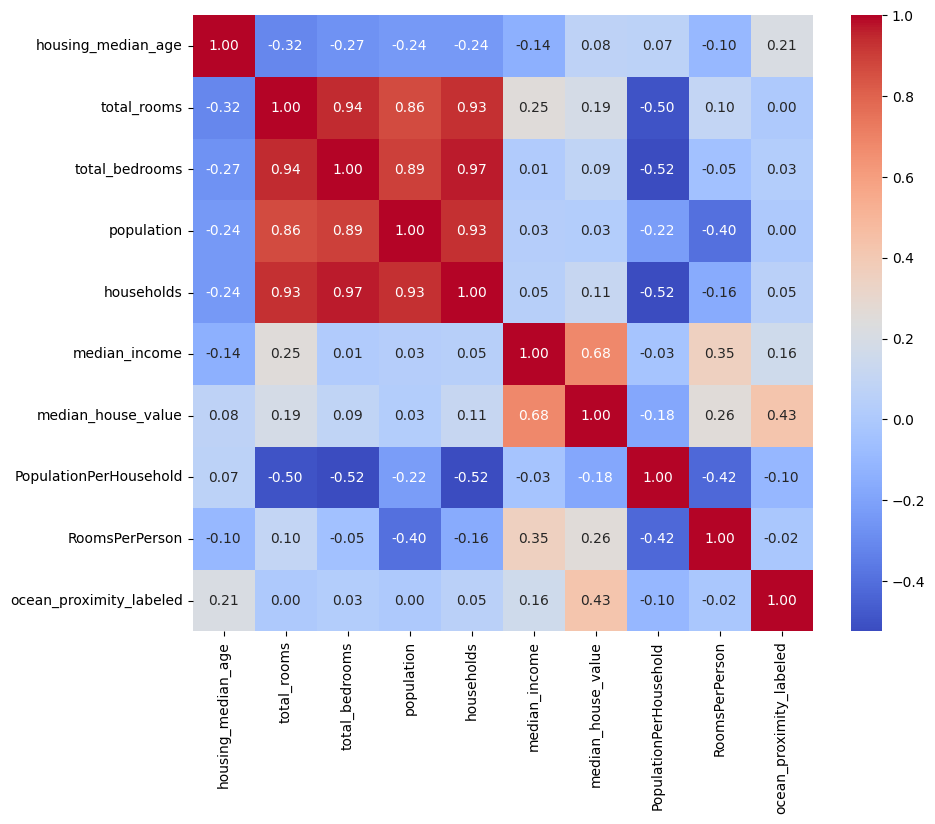

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cor_df = df.select_dtypes(include=[np.number])
corr_matrix = cor_df.corr()

plt.figure(figsize=(10, 8)) # Increase the figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

## Linear Regresion

### Define feature sets


In [ ]:
feature_sets = [
    # ['ocean_proximity_labeled'],
    # ['ocean_proximity'],
    # ['50km', 'median_income'],
    # ['50km'],
    # ['median_income'],
    # ['housing_median_age'],
    # ['total_rooms'],
    # ['total_bedrooms'],
    ['population'],
    ['households'],
    ['PopulationPerHousehold'],
    ['PopulationPerHousehold', 'households', 'population'],
    ['PopulationPerHousehold', 'households'],
    # ['RoomsPerPerson'],
    # ['RoomsPerPerson', '50km'],
    # ['50km'],
    # ['median_income'],
    # ['50km', 'ocean_proximity'],
    # ['50km', 'median_income', 'total_rooms'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity_labeled'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'ocean_proximity_labeled'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'housing_median_age'],
    ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'total_rooms', 'housing_median_age'],
    # ['50km', 'median_income', 'ocean_proximity', 'RoomsPerPerson', 'households', 'total_rooms', 'housing_median_age'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'total_rooms'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'total_rooms'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'total_rooms'],

    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'population', 'households', 'total_rooms'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'total_bedrooms'],
    # ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'housing_median_age'],
]

categorical_features = ['ocean_proximity', '50km']

print(feature_sets)

[['population'], ['households'], ['PopulationPerHousehold'], ['PopulationPerHousehold', 'households', 'population'], ['PopulationPerHousehold', 'households'], ['50km', 'median_income', 'PopulationPerHousehold', 'ocean_proximity', 'RoomsPerPerson', 'population', 'households', 'total_rooms', 'housing_median_age']]


### Iterate through feature sets


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

evaluation_results = []

for features in feature_sets:
    print(f"\nTraining model with features: {features}")

    # Split data
    X = df[features]
    y = df['median_house_value']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Identify numerical and categorical features
    numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

    # Create preprocessor
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore')

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Handle other columns not explicitly transformed
    )


    # Create and train pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Evaluate
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    evaluation_results.append({
        'Features': features,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R^2': r2
    })

    print(f"Mean Squared Error: {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"R^2 Score: {r2}")

    # # Plot residuals
    # residuals = y_test - y_pred

    # plt.figure(figsize=(10, 6))
    # plt.scatter(y_pred, residuals, alpha=0.5)
    # plt.axhline(y=0, color='r', linestyle='--')
    # plt.title(f'Residuals vs. Predicted Values ({features})')
    # plt.xlabel('Predicted Median House Value')
    # plt.ylabel('Residuals')
    # plt.grid(True)
    # plt.show()

    # plt.figure(figsize=(10, 6))
    # sns.histplot(residuals, kde=True)
    # plt.title(f'Distribution of Residuals ({features})')
    # plt.xlabel('Residuals')
    # plt.ylabel('Frequency')
    # plt.show()

# Convert results to DataFrame and display
evaluation_df = pd.DataFrame(evaluation_results)
print("\nEvaluation Results Summary:")
display(evaluation_df)


Training model with features: ['population']
Mean Squared Error: 0.3237230139087459
Root Mean Squared Error (RMSE): 0.5689666193273081
Mean Absolute Error (MAE): 0.4595498516561752
R^2 Score: 0.0006836535261320886

Training model with features: ['households']
Mean Squared Error: 0.3197377833851212
Root Mean Squared Error (RMSE): 0.5654536085171985
Mean Absolute Error (MAE): 0.45612063625546034
R^2 Score: 0.01298585582753331

Training model with features: ['PopulationPerHousehold']
Mean Squared Error: 0.3104001714485623
Root Mean Squared Error (RMSE): 0.5571356849534611
Mean Absolute Error (MAE): 0.4478681255297004
R^2 Score: 0.04181058513103364

Training model with features: ['PopulationPerHousehold', 'households', 'population']
Mean Squared Error: 0.30179298363574214
Root Mean Squared Error (RMSE): 0.5493568818498064
Mean Absolute Error (MAE): 0.44317352152145867
R^2 Score: 0.06838053261381116

Training model with features: ['PopulationPerHousehold', 'households']
Mean Squared Error:

,Features,MSE,RMSE,MAE,R^2
0,[population],0.323723,0.568967,0.459550,0.000684
1,[households],0.319738,0.565454,0.456121,0.012986
2,[PopulationPerHousehold],0.310400,0.557136,0.447868,0.041811
3,"[PopulationPerHousehold, households, population]",0.301793,0.549357,0.443174,0.068381
4,"[PopulationPerHousehold, households]",0.310648,0.557358,0.448053,0.041046
5,"[50km, median_income, PopulationPerHousehold, ...",0.093675,0.306064,0.226906,0.710829


### Summarize results


In [ ]:
# display(evaluation_results)
evaluation_df = pd.DataFrame(evaluation_results)
display(evaluation_df)

,Features,MSE,RMSE,MAE,R^2
0,[population],0.323723,0.568967,0.459550,0.000684
1,[households],0.319738,0.565454,0.456121,0.012986
2,[PopulationPerHousehold],0.310400,0.557136,0.447868,0.041811
3,"[PopulationPerHousehold, households, population]",0.301793,0.549357,0.443174,0.068381
4,"[PopulationPerHousehold, households]",0.310648,0.557358,0.448053,0.041046
5,"[50km, median_income, PopulationPerHousehold, ...",0.093675,0.306064,0.226906,0.710829


Comparing the models based on the evaluation metrics:
- The model using '50km' and 'median_income' features performs the best across all metrics (lowest MSE, RMSE, MAE, and highest R^2).
- The models using 'ocean_proximity_labeled' and 'ocean_proximity' have identical performance, which is expected as 'ocean_proximity_labeled' is a direct mapping of 'ocean_proximity'. Their performance is the worst among the four models.
- The model using 'RoomsPerPerson' and '50km' performs better than the 'ocean_proximity' models but not as well as the '50km' and 'median_income' model.

This suggests that 'median_income' and the proximity to major cities ('50km') are strong predictors of 'median_house_value'.

## Gradient Boosting

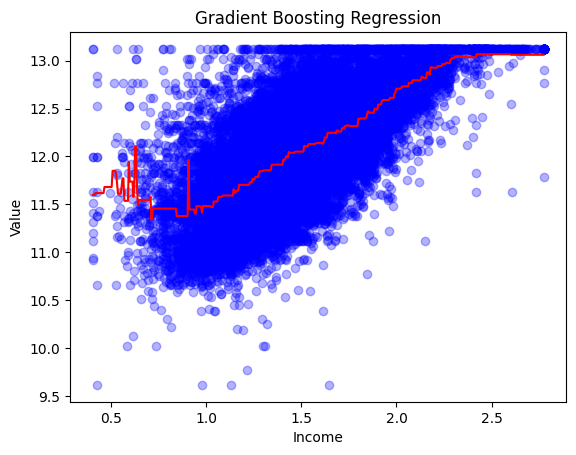

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Select the feature and target, ensuring X is a DataFrame
X = df[['median_income']]
y = df['median_house_value']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
gbr.fit(X_train, y_train)

# Generate data for plotting the regression line, ensuring X_plot is 2D
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
X_plot = pd.DataFrame(X_plot, columns=['median_income']) # Add column name
y_plot = gbr.predict(X_plot)

# Plot original data and the regression line
plt.scatter(X, y, color='blue', alpha=0.3)
plt.plot(X_plot, y_plot, color='red')
plt.xlabel('Income')
plt.ylabel('Value')
plt.title('Gradient Boosting Regression')
plt.show()

# Inspect the first few estimators (trees)
# Note: GradientBoostingRegressor stores estimators as a 2D array (n_estimators, n_classes)
# For regression, n_classes is 1, so we access the tree with tree[0]
# print("Inspecting first 5 estimators (trees):")
# for i, tree in enumerate(gbr.estimators_[:5]):
#     print(f"Arbore {i+1} predicții min/max:", tree[0].predict(X_plot).min(), tree[0].predict(X_plot).max())

## SVR

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Handle missing values (typically in total_bedrooms column)
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Handle categorical variables (ocean_proximity)
if 'ocean_proximity' in df.columns:
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
else:
    df_encoded = df.copy()

# Separate features and target
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling (crucial for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Basic SVR model
print("\n=== Basic SVR Model ===")
svr_basic = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_basic.fit(X_train_scaled, y_train)

# Predictions
y_pred_basic = svr_basic.predict(X_test_scaled)

# Evaluation metrics
mse_basic = mean_squared_error(y_test, y_pred_basic)
rmse_basic = np.sqrt(mse_basic)
r2_basic = r2_score(y_test, y_pred_basic)
mae_basic = mean_absolute_error(y_test, y_pred_basic)

print(f"Basic SVR Results:")
print(f"RMSE: {rmse_basic:.2f}")
print(f"R²: {r2_basic:.4f}")
print(f"MAE: {mae_basic:.2f}")

# Hyperparameter tuning with GridSearchCV
print("\n=== Hyperparameter Tuning ===")
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2, 0.5],
    'kernel': ['linear', 'rbf']
}

svr_grid = SVR()
grid_search = GridSearchCV(svr_grid, param_grid, cv=5,
                          scoring='neg_mean_squared_error',
                          n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {np.sqrt(-grid_search.best_score_):.2f}")

# Best model predictions
best_svr = grid_search.best_estimator_
y_pred_best = best_svr.predict(X_test_scaled)

# Evaluation metrics for best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)

print(f"\nBest SVR Results:")
print(f"RMSE: {rmse_best:.2f}")
print(f"R²: {r2_best:.4f}")
print(f"MAE: {mae_best:.2f}")

# Comparison of different kernels
print("\n=== Kernel Comparison ===")
kernels = ['linear', 'rbf', 'poly']
results = {}

for kernel in kernels:
    svr = SVR(kernel=kernel, C=10, epsilon=0.1)
    svr.fit(X_train_scaled, y_train)
    y_pred = svr.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[kernel] = {'RMSE': rmse, 'R²': r2}
    print(f"{kernel.upper()} kernel - RMSE: {rmse:.2f}, R²: {r2:.4f}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Actual vs Predicted (Best Model)
axes[0,0].scatter(y_test, y_pred_best, alpha=0.6)
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual House Values')
axes[0,0].set_ylabel('Predicted House Values')
axes[0,0].set_title('SVR: Actual vs Predicted Values')
axes[0,0].grid(True)

# Plot 2: Residuals
residuals = y_test - y_pred_best
axes[0,1].scatter(y_pred_best, residuals, alpha=0.6)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residual Plot')
axes[0,1].grid(True)

# Plot 3: Feature importance (for linear kernel)
if grid_search.best_params_['kernel'] == 'linear':
    feature_names = X.columns
    coefficients = best_svr.coef_[0]
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'coefficient': np.abs(coefficients)
    }).sort_values('coefficient', ascending=False)

    axes[1,0].barh(feature_importance['feature'][:10], feature_importance['coefficient'][:10])
    axes[1,0].set_xlabel('Absolute Coefficient Value')
    axes[1,0].set_title('Feature Importance (Linear SVR)')
else:
    axes[1,0].text(0.5, 0.5, 'Feature importance not available\nfor non-linear kernels',
                   ha='center', va='center', transform=axes[1,0].transAxes)
    axes[1,0].set_title('Feature Importance')

# Plot 4: Model comparison
models = ['Basic SVR', 'Best SVR']
rmse_scores = [rmse_basic, rmse_best]
r2_scores = [r2_basic, r2_best]

x_pos = np.arange(len(models))
axes[1,1].bar(x_pos - 0.2, rmse_scores, 0.4, label='RMSE', alpha=0.7)
axes[1,1].set_ylabel('RMSE')
axes[1,1].set_xlabel('Models')
axes[1,1].set_title('Model Performance Comparison')
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(models)

# Add R² as text annotations
for i, (rmse, r2) in enumerate(zip(rmse_scores, r2_scores)):
    axes[1,1].text(i, rmse + 1000, f'R²: {r2:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Final model summary
print("\n=== Final Model Summary ===")
print(f"Dataset size: {df.shape[0]} samples, {df.shape[1]-1} features")
print(f"Best SVR configuration: {grid_search.best_params_}")
print(f"Test set performance:")
print(f"  - RMSE: ${rmse_best:,.2f}")
print(f"  - R²: {r2_best:.4f}")
print(f"  - MAE: ${mae_best:,.2f}")
print(f"Number of support vectors: {best_svr.n_support_}")

/tmp/ipython-input-819049265.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)



=== Basic SVR Model ===


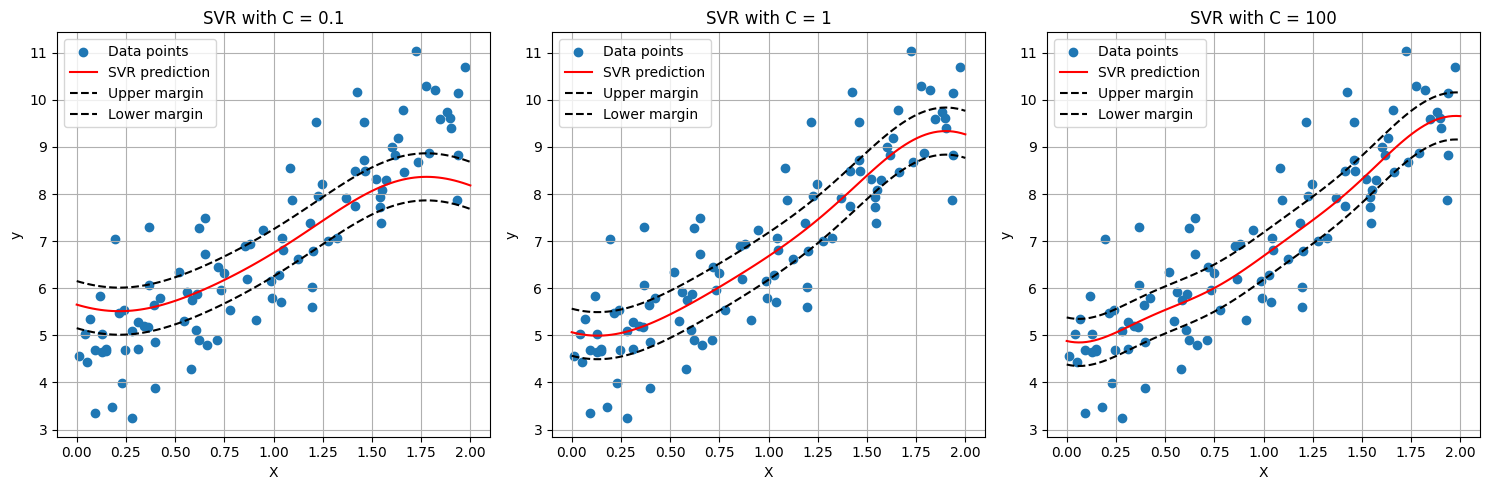

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Generate some synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Define different C values to explore
c_values = [0.1, 1, 100]

plt.figure(figsize=(15, 5))

for i, C in enumerate(c_values):
    plt.subplot(1, len(c_values), i + 1)
    svr = SVR(kernel='rbf', C=C, epsilon=0.5)
    svr.fit(X, y.ravel())

    # Plot the data points
    plt.scatter(X, y, label='Data points')

    # Plot the SVR prediction line
    X_plot = np.linspace(0, 2, 100).reshape(-1, 1)
    y_plot = svr.predict(X_plot)
    plt.plot(X_plot, y_plot, color='red', label='SVR prediction')

    # Plot the margins (epsilon tube)
    plt.plot(X_plot, y_plot + svr.epsilon, 'k--', label='Upper margin')
    plt.plot(X_plot, y_plot - svr.epsilon, 'k--', label='Lower margin')

    plt.title(f'SVR with C = {C}')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()